In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd
df = pd.read_csv("Iris.csv")
df = df[df['Species'] != 'Species']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

#Loading dataset

In [ ]:
columns=['Sepal length','Sepal width','Petal length','petal width','Class_labels']
df=pd.read_csv('Iris.csv',names=columns)
df.head()

,Sepal length,Sepal width,Petal length,petal width,Class_labels
Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa


#visualization of our dataset

In [ ]:
df.describe()

,Sepal length,Sepal width,Petal length,petal width,Class_labels
count,151,151,151,151,151
unique,36,24,44,23,4
top,5.0,3.0,1.5,0.2,Iris-setosa
freq,10,26,14,28,50


In [ ]:
print(df.dtypes)

Sepal length    object
Sepal width     object
Petal length    object
petal width     object
Class_labels    object
dtype: object


In [ ]:
X = df.drop('Class_labels', axis=1)
Y = df['Class_labels']

In [ ]:
df['Sepal length'] = pd.to_numeric(df['Sepal length'], errors='coerce')
df['Sepal width'] = pd.to_numeric(df['Sepal width'], errors='coerce')
df['Petal length'] = pd.to_numeric(df['Petal length'], errors='coerce')
df['petal width'] = pd.to_numeric(df['petal width'], errors='coerce')

In [ ]:
df = df.dropna()

In [ ]:
print(df.dtypes)

Sepal length    float64
Sepal width     float64
Petal length    float64
petal width     float64
Class_labels     object
dtype: object


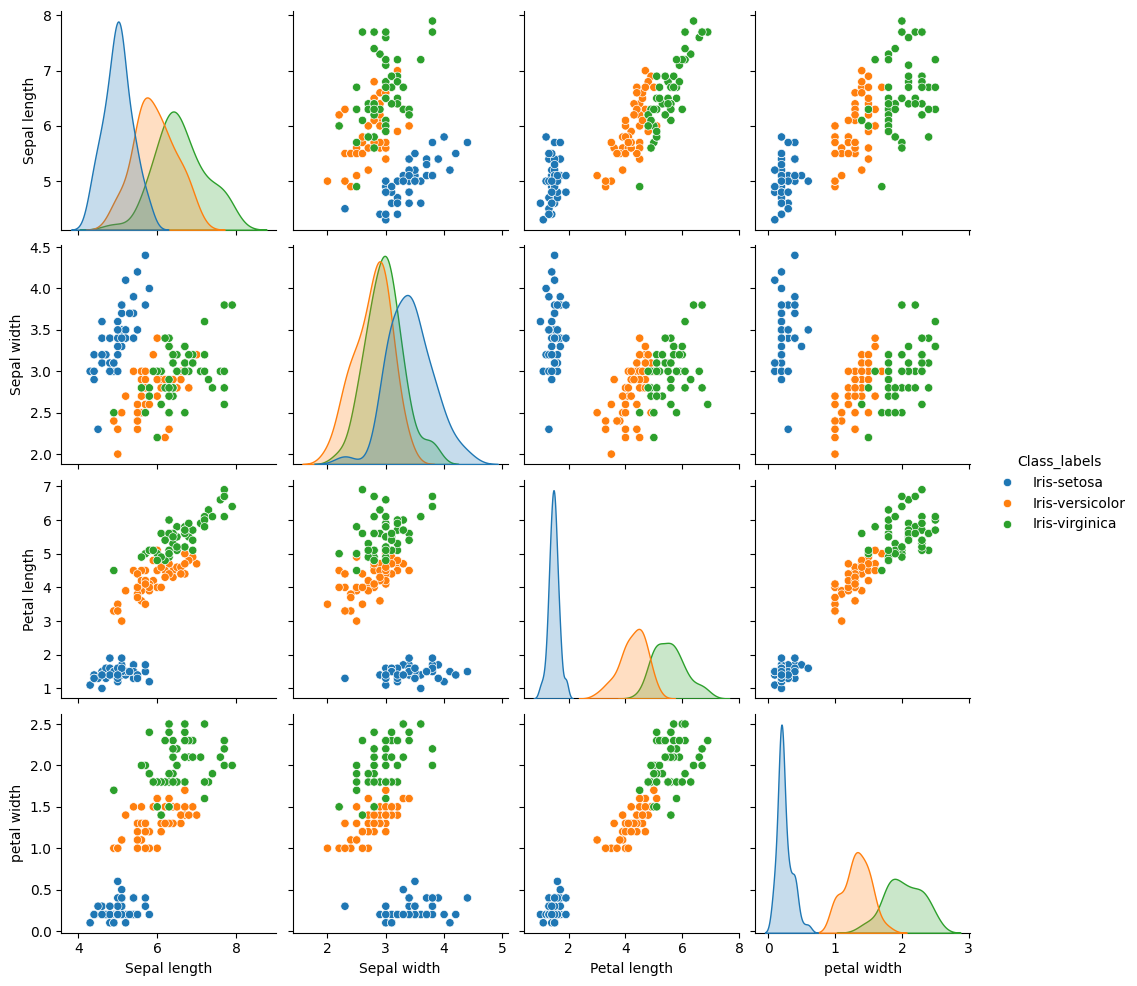

In [ ]:
import seaborn as sns
sns.pairplot(df, hue='Class_labels')

#seperating input cols and the output cols

In [ ]:
data=df.values
X=data[:,0:4]
Y=data[:,4]
print(Y)

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor

#splitting the data nto training and testing

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
print(Y_test)

['Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor']


#model1:support vector machine Alg


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# One-step pipeline: impute + train
model_svc = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # fill NaN with column mean
    ('svc', SVC())
])

model_svc.fit(X_train, Y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('svc', SVC())])

In [ ]:
from sklearn.impute import SimpleImputer

# Create imputer (mean strategy)
imputer = SimpleImputer(strategy='mean')

# Fit on training data and transform
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train the model
model_svc = SVC()
model_svc.fit(X_train, Y_train)

# Make predictions
prediction1 = model_svc.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, prediction1) * 100)

# Print actual vs predicted
for i in range(len(prediction1)):
    print("Actual:", Y_test[i], "Predicted:", prediction1[i])

Accuracy: 100.0
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-virgini

#model2:logistic reg

In [ ]:
from sklearn.impute import SimpleImputer

X_train = SimpleImputer(strategy='mean').fit_transform(X_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_LR = LogisticRegression(max_iter=200)
model_LR.fit(X_train, Y_train)

LogisticRegression(max_iter=200)

In [ ]:
prediction2 = model_LR.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,prediction2)*100)
Y_test = list(Y_test)

for i in range(len(prediction2)):
    print("Actual:", Y_test[i], "Predicted:", prediction2[i])

93.33333333333333
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-virginica
Actual:

#model3 :Decision tree classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_DTC=DecisionTreeClassifier()
model_DTC.fit(X_train,Y_train)

DecisionTreeClassifier()

In [ ]:
prediction3 = model_DTC.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,prediction3)*100)
Y_test = list(Y_test)

for i in range(len(prediction3)):
    print("Actual:", Y_test[i], "Predicted:", prediction3[i])

90.0
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-versicolor Predicted: Iris-versicolor
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-versicolor
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-setosa Predicted: Iris-setosa
Actual: Iris-virginica Predicted: Iris-virginica
Actual: Iris-versico

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction2,zero_division=0))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.85      1.00      0.92        11
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.95      0.93      0.94        30
   weighted avg       0.94      0.93      0.93        30



In [ ]:
X_new = np.array([[3,2,1,0.2],[4.9,2.2,3.8,1.1],[5.3,2.5,4.6,1.9]])
prediction = model_svc.predict(X_new)
print("prediction of species: {}".format(prediction))

prediction of species: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
